# Chapter 5: Algorithms

We use a single classical problem — **Climbing Stairs** — to motivate and compare five distinct algorithmic strategies:

| Method | Time | Space |
|---|---|---|
| 1. Backtracking (DFS) | O(2ⁿ) | O(2ⁿ) |
| 2. Recursive DFS | O(2ⁿ) | O(n) |
| 3. Memoised DFS | O(n) | O(n) |
| 4. Dynamic Programming | O(n) | O(n) → O(1) |
| 5. Divide & Conquer (matrix exp) | O(log n) | O(log n) |

We also cover **Breadth-First Search (BFS)** and the **Minimum Path Sum** DP problem.

> **Problem statement**: Given a staircase with n steps where you can climb 1 or 2 steps at a time, how many distinct ways are there to reach the top?

In [1]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

---
## 1. Backtracking — Exhaustive Search

**Backtracking** explores all possible paths by making a choice, recursing, then *undoing* the choice (retreating).  
The three core steps are: **Prune → Try → Retreat**.

### Generic framework

```python
def backtrack(problem, state, choices, result):
    if is_solution(state, problem):      # found a complete solution
        result.append(state[:])          # save a copy
        return
    for choice in generate_choices(state, problem):
        if is_valid(choice, state, problem):  # Prune invalid branches
            state.append(choice)              # Try
            backtrack(problem, state, choices, result)
            state.pop()                       # Retreat
```

In [2]:
def backtrack(n: int, state: int, choices: list, path: list, result: list) -> None:
    """Enumerate every valid path from step 0 to step n."""
    if state == n:                    # is_solution: reached the top
        result.append(path[:])        # save a copy of the current path
        return
    for choice in choices:
        if state + choice <= n:       # Prune: don't overshoot
            path.append(choice)       # Try
            backtrack(n, state + choice, choices, path, result)
            path.pop()                # Retreat

def climbing_stairs_backtrack(n: int):
    """Return all paths and their count.  Time O(2^n), Space O(2^n)."""
    result = []
    backtrack(n, state=0, choices=[1, 2], path=[], result=result)
    return result

paths = climbing_stairs_backtrack(4)
print(f"n=4: {len(paths)} ways")
for p in paths:
    print(" ", p)

n=4: 5 ways
  [1, 1, 1, 1]
  [1, 1, 2]
  [1, 2, 1]
  [2, 1, 1]
  [2, 2]


**Complexity**: O(2ⁿ) — every step can branch into 2 choices, and the recursion tree has depth n.  
We also store all paths, so space is O(2ⁿ). Fine for small n, impractical for large n.

---
## 2. Recursive DFS (without memoisation)

If we only care about the **count** (not the paths), we can write a cleaner recursion:

$$dp[i] = dp[i-1] + dp[i-2]$$

But without caching, many sub-problems are recomputed: `dp[n-2]` is computed from both `dp[n]` and `dp[n-1]`.
The recursion tree has O(2ⁿ) nodes.

In [3]:
def dfs(i: int) -> int:
    """Naive recursion.  Time O(2^n), Space O(n) call stack."""
    if i == 1 or i == 2:
        return i     # dp[1]=1, dp[2]=2
    return dfs(i - 1) + dfs(i - 2)

def climbing_stairs_dfs(n: int) -> int:
    return dfs(n)

for n in range(1, 11):
    print(f"n={n:2d}: {climbing_stairs_dfs(n)} ways")

n= 1: 1 ways
n= 2: 2 ways
n= 3: 3 ways
n= 4: 5 ways
n= 5: 8 ways
n= 6: 13 ways
n= 7: 21 ways
n= 8: 34 ways
n= 9: 55 ways
n=10: 89 ways


---
## 3. Memoised Search (Top-Down DP)

**Key insight**: cache every computed dp[i] so that each sub-problem is solved exactly once.  
This reduces time from O(2ⁿ) → **O(n)** while keeping O(n) space.

In [4]:
def dfs_mem(i: int, mem: list) -> int:
    """Memoised DFS.  Time O(n), Space O(n)."""
    if i == 1 or i == 2:
        return i
    if mem[i] != -1:       # already computed
        return mem[i]
    mem[i] = dfs_mem(i - 1, mem) + dfs_mem(i - 2, mem)
    return mem[i]

def climbing_stairs_memo(n: int) -> int:
    mem = [-1] * (n + 1)
    return dfs_mem(n, mem)

# Performance — compare with naive recursion
n = 35
t0 = time.perf_counter(); r_dfs  = climbing_stairs_dfs(n);  t_dfs  = time.perf_counter() - t0
t0 = time.perf_counter(); r_memo = climbing_stairs_memo(n); t_memo = time.perf_counter() - t0
print(f"n={n}: dfs={t_dfs:.3f}s  memo={t_memo:.6f}s")
print(f"Results agree: {r_dfs == r_memo}")

n=35: dfs=0.634s  memo=0.000034s
Results agree: True


---
## 4. Dynamic Programming — Bottom-Up

DP inverts memoisation: instead of recursing down and caching on the way up, we fill a table **from the smallest sub-problems upward**.

**Three DP components**:
- **DP table**: `dp[i]` = number of ways to reach step i
- **Initial state**: `dp[1]=1`, `dp[2]=2`
- **Transition equation**: `dp[i] = dp[i-1] + dp[i-2]`

In [5]:
def climbing_stairs_dp(n: int) -> int:
    """Bottom-up DP.  Time O(n), Space O(n)."""
    if n <= 2:
        return n
    dp = [0] * (n + 1)
    dp[1], dp[2] = 1, 2
    for i in range(3, n + 1):
        dp[i] = dp[i - 1] + dp[i - 2]
    return dp[n]

# Space-optimised: only keep the last two values → O(1) space
def climbing_stairs_dp_opt(n: int) -> int:
    """Space-optimised DP (rolling variables).  Time O(n), Space O(1)."""
    if n <= 2:
        return n
    a, b = 1, 2
    for _ in range(3, n + 1):
        a, b = b, a + b
    return b

for n in [1, 5, 10, 20]:
    print(f"n={n:2d}: dp={climbing_stairs_dp(n)}, opt={climbing_stairs_dp_opt(n)}")

n= 1: dp=1, opt=1
n= 5: dp=8, opt=8
n=10: dp=89, opt=89
n=20: dp=10946, opt=10946


---
## 5. Divide and Conquer — Matrix Exponentiation O(log n)

The Fibonacci-like recurrence can be expressed in matrix form:

$$
\begin{bmatrix} dp[i] \\ dp[i-1] \end{bmatrix} = 
\underbrace{\begin{bmatrix} 1 & 1 \\ 1 & 0 \end{bmatrix}}_{A}
\begin{bmatrix} dp[i-1] \\ dp[i-2] \end{bmatrix}
$$

So $dp[n]$ is the top-left element of $A^{n-1}$ times the initial vector $[1, 1]^T$.

**Binary exponentiation** computes $A^n$ in O(log n) matrix multiplications by halving the exponent each step:
- If n is even: $A^n = (A^{n/2})^2$
- If n is odd: $A^n = (A^{(n-1)/2})^2 \cdot A$

In [6]:
def binpow(A: np.ndarray, n: int) -> np.ndarray:
    """Matrix binary exponentiation: A^n in O(log n) multiplications."""
    if n == 0:
        return np.eye(A.shape[0], dtype=object)  # identity matrix
    half = binpow(A, n // 2)
    if n % 2 == 0:
        return half @ half
    else:
        return half @ half @ A

def climbing_stairs_binpow(n: int) -> int:
    """O(log n) time via matrix exponentiation."""
    A = np.array([[1, 1], [1, 0]], dtype=object)
    return int(binpow(A, n)[0][0])

for n in [1, 5, 10, 20, 50]:
    print(f"n={n:2d}: binpow={climbing_stairs_binpow(n)}, dp={climbing_stairs_dp_opt(n)}")

n= 1: binpow=1, dp=1
n= 5: binpow=8, dp=8
n=10: binpow=89, dp=89
n=20: binpow=10946, dp=10946
n=50: binpow=20365011074, dp=20365011074


### 5.1 Divide and Conquer: Binary Search

Binary search is the canonical divide-and-conquer **search** algorithm.  
Each step discards half the search space → O(log n).

In [7]:
def binary_search_rec(nums: list, target: int, lo: int, hi: int) -> int:
    """Recursive binary search.  Time O(log n), Space O(log n) call stack."""
    if lo > hi:
        return -1
    mid = (lo + hi) // 2
    if nums[mid] == target:
        return mid
    elif nums[mid] < target:
        return binary_search_rec(nums, target, mid + 1, hi)
    else:
        return binary_search_rec(nums, target, lo, mid - 1)

def binary_search(nums: list, target: int) -> int:
    return binary_search_rec(nums, target, 0, len(nums) - 1)

nums = list(range(0, 20, 2))   # [0, 2, 4, 6, …, 18]
print("Array:", nums)
for t in [6, 7, 18]:
    idx = binary_search(nums, t)
    print(f"  search({t}) → index {idx}")

Array: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
  search(6) → index 3
  search(7) → index -1
  search(18) → index 9


---
## 6. Breadth-First Search (BFS)

**Problem variant**: you can climb `steps` steps at a time (e.g., [1, 3, 5]).  
Find the **minimum number of moves** to reach step n.

BFS is perfect here because it explores states **layer by layer** (same number of moves), so the first time we reach step n we have the optimal (fewest-moves) answer.

The BFS template:
1. Put the start state in a queue
2. While queue non-empty: pop front, check if goal, otherwise enqueue valid next states
3. Track visited states to avoid cycles

In [8]:
def min_moves_to_climb(n: int, steps: list) -> int:
    """BFS: minimum number of moves to reach step n.  Time O(n), Space O(n)."""
    queue   = deque([(0, 0)])  # (current_position, moves_so_far)
    visited = set()

    while queue:
        position, moves = queue.popleft()

        if position == n:
            return moves

        for step in steps:
            nxt = position + step
            if nxt <= n and nxt not in visited:
                visited.add(nxt)
                queue.append((nxt, moves + 1))

    return -1   # unreachable

print("steps=[1,2], n=5  →", min_moves_to_climb(5, [1, 2]))    # 3: 2+2+1
print("steps=[1,3,5], n=10 →", min_moves_to_climb(10, [1, 3, 5]))  # 2: 5+5
print("steps=[2], n=7  →", min_moves_to_climb(7, [2]))           # -1 (can't reach 7)

steps=[1,2], n=5  → 3
steps=[1,3,5], n=10 → 2
steps=[2], n=7  → -1


### When to use BFS vs DP?

| Goal | Algorithm |
|---|---|
| Count all possible solutions | DFS / Backtracking |
| Shortest path (unweighted) | **BFS** |
| Optimal value (overlapping sub-problems) | **Dynamic Programming** |

---
## 7. Dynamic Programming: Minimum Path Sum

**Problem**: Given an n×m grid of non-negative costs, find the minimum-cost path from top-left [0,0] to bottom-right [n-1, m-1] moving only right or down.

**DP formulation**:
- State: `dp[i][j]` = minimum cost to reach cell (i, j)
- Transition: `dp[i][j] = min(dp[i-1][j], dp[i][j-1]) + grid[i][j]`
- Boundaries: first row can only come from the left; first column from above.

In [9]:
def min_path_sum_dp(grid: list) -> int:
    """Full DP table.  Time O(nm), Space O(nm)."""
    n, m = len(grid), len(grid[0])
    dp = [[0] * m for _ in range(n)]
    dp[0][0] = grid[0][0]

    # Initialise first row (can only come from the left)
    for j in range(1, m):
        dp[0][j] = dp[0][j - 1] + grid[0][j]

    # Initialise first column (can only come from above)
    for i in range(1, n):
        dp[i][0] = dp[i - 1][0] + grid[i][0]

    # Fill the rest
    for i in range(1, n):
        for j in range(1, m):
            dp[i][j] = min(dp[i - 1][j], dp[i][j - 1]) + grid[i][j]

    return dp[n - 1][m - 1]


def min_path_sum_dp_opt(grid: list) -> int:
    """Space-optimised: single row.  Time O(nm), Space O(m)."""
    n, m = len(grid), len(grid[0])
    dp = [0] * m
    dp[0] = grid[0][0]
    for j in range(1, m):
        dp[j] = dp[j - 1] + grid[0][j]
    for i in range(1, n):
        dp[0] += grid[i][0]
        for j in range(1, m):
            dp[j] = min(dp[j - 1], dp[j]) + grid[i][j]
    return dp[m - 1]


# Example grid
grid = [
    [1, 3, 1],
    [1, 5, 1],
    [4, 2, 1]
]

print("Grid:")
for row in grid:
    print(" ", row)
print(f"\nMin path sum (full DP)     : {min_path_sum_dp(grid)}")     # 7
print(f"Min path sum (space-opt)   : {min_path_sum_dp_opt(grid)}")   # 7

Grid:
  [1, 3, 1]
  [1, 5, 1]
  [4, 2, 1]

Min path sum (full DP)     : 7
Min path sum (space-opt)   : 7


### Visualise the optimal path

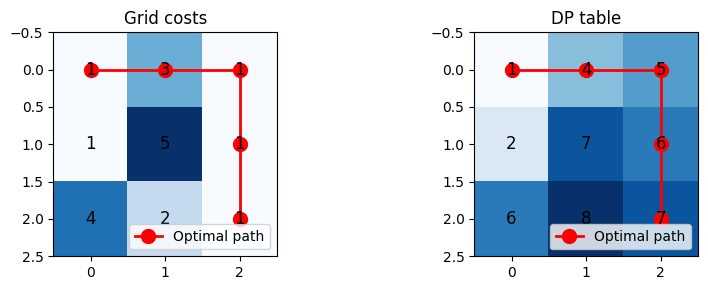

In [10]:
def min_path_sum_with_trace(grid):
    n, m = len(grid), len(grid[0])
    dp = [[0]*m for _ in range(n)]
    dp[0][0] = grid[0][0]
    for j in range(1, m): dp[0][j] = dp[0][j-1] + grid[0][j]
    for i in range(1, n): dp[i][0] = dp[i-1][0] + grid[i][0]
    for i in range(1, n):
        for j in range(1, m):
            dp[i][j] = min(dp[i-1][j], dp[i][j-1]) + grid[i][j]

    # Traceback optimal path
    i, j = n-1, m-1
    path = [(i, j)]
    while i > 0 or j > 0:
        if i == 0: j -= 1
        elif j == 0: i -= 1
        elif dp[i-1][j] < dp[i][j-1]: i -= 1
        else: j -= 1
        path.append((i, j))
    return dp, path[::-1]

dp_table, path = min_path_sum_with_trace(grid)

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, data, title in zip(axes, [grid, dp_table], ["Grid costs", "DP table"]):
    im = ax.imshow(data, cmap='Blues')
    for i in range(len(data)):
        for j in range(len(data[0])):
            ax.text(j, i, data[i][j], ha='center', va='center', fontsize=12)
    # Overlay path
    xs = [p[1] for p in path]; ys = [p[0] for p in path]
    ax.plot(xs, ys, 'r-o', lw=2, ms=10, label='Optimal path')
    ax.set_title(title); ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 8. Algorithm Comparison

Let's time all five climbing-stairs methods for a range of n.

In [11]:
def climbing_stairs_closed(n: int) -> int:
    """Closed-form via Binet's formula.  Floating-point so may be inaccurate for large n."""
    sqrt5 = math.sqrt(5)
    return round(((1 + sqrt5) / 2)**(n + 1) / sqrt5 - ((1 - sqrt5) / 2)**(n + 1) / sqrt5)

methods = [
    ("DFS (naive)",    climbing_stairs_dfs,    range(1, 26)),
    ("Memo",           climbing_stairs_memo,   range(1, 201)),
    ("DP O(n)",        climbing_stairs_dp,     range(1, 201)),
    ("DP O(1) space",  climbing_stairs_dp_opt, range(1, 201)),
    ("Binpow O(log n)",climbing_stairs_binpow, range(1, 201)),
]

# Verify correctness up to n=20
print("Correctness check (n=10):")
for name, fn, _ in methods:
    print(f"  {name:25s}: {fn(10)}")
print("Expected: 89")

Correctness check (n=10):
  DFS (naive)              : 89
  Memo                     : 89
  DP O(n)                  : 89
  DP O(1) space            : 89
  Binpow O(log n)          : 89
Expected: 89


In [12]:
import sys

# Python's default recursion limit is ~1000.
# Memoised DFS has recursion depth = n, so we cap it at 500 here.
# The DP and binpow methods have no such limit.

ns_dp     = [100, 500, 1000, 5000, 10_000]   # safe for iterative methods
ns_memo   = [100, 200, 300, 400, 500]         # capped for recursive memo

print("Benchmarks (mean over 200 calls each):")
print()

# Memo (capped at n=500 due to Python recursion limit)
print(f"{'Memo (n≤500)':25s}: ", end="")
memo_times = []
for n in ns_memo:
    t0 = time.perf_counter()
    for _ in range(200): climbing_stairs_memo(n)
    memo_times.append((time.perf_counter() - t0) / 200)
print("  ".join(f"{1e6*t:.1f}μs" for t in memo_times))
print(f"  n values: {ns_memo}")
print()

# Iterative methods — no recursion limit
for name, fn in [("DP O(n)", climbing_stairs_dp),
                  ("DP O(1) space", climbing_stairs_dp_opt),
                  ("Binpow O(log n)", climbing_stairs_binpow)]:
    times = []
    for n in ns_dp:
        t0 = time.perf_counter()
        for _ in range(200): fn(n)
        times.append((time.perf_counter() - t0) / 200)
    print(f"{name:25s}: " + "  ".join(f"{1e6*t:.1f}μs" for t in times))

print(f"\nn values (DP/Binpow): {ns_dp}")
print("\nNote: Memo uses recursion depth=n, so Python's ~1000 recursion limit")
print("constrains it to small n. Use iterative DP for large n.")


Benchmarks (mean over 200 calls each):

Memo (n≤500)             : 10.3μs  26.0μs  41.1μs  61.2μs  74.5μs
  n values: [100, 200, 300, 400, 500]



DP O(n)                  : 3.9μs  23.8μs  55.2μs  522.5μs  2034.7μs


DP O(1) space            : 2.0μs  12.6μs  30.9μs  348.3μs  1569.7μs
Binpow O(log n)          : 10.9μs  15.7μs  17.4μs  55.7μs  145.2μs

n values (DP/Binpow): [100, 500, 1000, 5000, 10000]

Note: Memo uses recursion depth=n, so Python's ~1000 recursion limit
constrains it to small n. Use iterative DP for large n.


---
## 9. Summary

| Algorithm | Idea | Time | Space | Key Data Structure |
|---|---|---|---|---|
| **Backtracking** | Exhaustive DFS, undo choices | O(2ⁿ) | O(2ⁿ) | Recursion + list |
| **Recursive DFS** | Decompose problem | O(2ⁿ) | O(n) | Call stack |
| **Memoised DFS** | Cache sub-results (top-down) | O(n) | O(n) | Array / dict |
| **DP (table)** | Build up from base (bottom-up) | O(n) | O(n) | Array |
| **DP (rolling)** | Keep only last 2 values | O(n) | **O(1)** | Two variables |
| **Div & Conquer** | Halve problem recursively | **O(log n)** | O(log n) | Matrix + recursion |
| **BFS** | Explore layer by layer | O(V+E) | O(V) | Queue + visited set |

**When to choose DP**: overlapping sub-problems + optimal substructure + decision-tree model.  
**When to choose BFS**: shortest path in unweighted graph / state space.